# Project - Strava Fitness Analysis

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import seaborn as sns

In [6]:
#  Load the CSV file
activity_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/dailyActivity_merged.csv")
heart_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/heartrate_seconds_merged.csv")
hr_intensity_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/hourlyIntensities_merged.csv")
min_sleep_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/minuteSleep_merged.csv")
sleepDay_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/sleepDay_merged.csv")
weightInfo_df = pd.read_csv("E:/Analytics PDF/Strava Fitness/Fitabase Datas/weightLogInfo_merged.csv")

print(activity_df.info())
activity_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [7]:
#Convert colunms Date from object to datetime format

activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate']) 
heart_df['Time'] = pd.to_datetime(heart_df['Time'], format= 'mixed')
hr_intensity_df['ActivityHour'] = pd.to_datetime(hr_intensity_df['ActivityHour'])
min_sleep_df['date'] = pd.to_datetime(min_sleep_df['date'])
sleepDay_df['SleepDay'] = pd.to_datetime(sleepDay_df['SleepDay'])
weightInfo_df['Date'] = pd.to_datetime(weightInfo_df['Date'])

#Check the structure of the dataset
print("\nDataset Info:")
activity_df.info()
activity_df.head()

C:\Users\visha\AppData\Local\Temp\ipykernel_20028\3510958400.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hr_intensity_df['ActivityHour'] = pd.to_datetime(hr_intensity_df['ActivityHour'])



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  Lightly

C:\Users\visha\AppData\Local\Temp\ipykernel_20028\3510958400.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleepDay_df['SleepDay'] = pd.to_datetime(sleepDay_df['SleepDay'])
C:\Users\visha\AppData\Local\Temp\ipykernel_20028\3510958400.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weightInfo_df['Date'] = pd.to_datetime(weightInfo_df['Date'])


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [8]:
#  Check for missing values

print("\nMissing values per column:")
print(activity_df.isnull().sum())
print(heart_df.isnull().sum())
print(hr_intensity_df.isnull().sum())
print(min_sleep_df.isnull().sum())
print(sleepDay_df.isnull().sum())
print(weightInfo_df.isnull().sum())


Missing values per column:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64
Id       0
Time     0
Value    0
dtype: int64
Id                  0
ActivityHour        0
TotalIntensity      0
AverageIntensity    0
dtype: int64
Id       0
date     0
value    0
logId    0
dtype: int64
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtyp

In [9]:
# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(activity_df.duplicated().sum())
print(heart_df.duplicated().sum())
print(hr_intensity_df.duplicated().sum())
print(min_sleep_df.duplicated().sum())
print(sleepDay_df.duplicated().sum())
print(weightInfo_df.duplicated().sum())

print("\nDrop duplicate rows:")

# Drop any duplicate rows (if found)
activity_df.drop_duplicates(inplace=True)
print(heart_df.drop_duplicates(inplace=True))
print(hr_intensity_df.drop_duplicates(inplace=True))    
print(min_sleep_df.drop_duplicates(inplace=True))     
print(sleepDay_df.drop_duplicates(inplace=True))       
print(weightInfo_df.drop_duplicates(inplace=True))  


Number of duplicate rows:
0
286235
0
543
3
0

Drop duplicate rows:
None
None
None
None
None


In [10]:
# Check summary statistics
print("\nDescriptive Statistics:")
print(activity_df.describe())
print(heart_df.describe())
print(hr_intensity_df.describe())    
print(min_sleep_df.describe())     
print(sleepDay_df.describe())       
weightInfo_df.describe()


Descriptive Statistics:
                 Id                   ActivityDate    TotalSteps  \
count  9.400000e+02                            940    940.000000   
mean   4.855407e+09  2016-04-26 06:53:37.021276672   7637.910638   
min    1.503960e+09            2016-04-12 00:00:00      0.000000   
25%    2.320127e+09            2016-04-19 00:00:00   3789.750000   
50%    4.445115e+09            2016-04-26 00:00:00   7405.500000   
75%    6.962181e+09            2016-05-04 00:00:00  10727.000000   
max    8.877689e+09            2016-05-12 00:00:00  36019.000000   
std    2.424805e+09                            NaN   5087.150742   

       TotalDistance  TrackerDistance  LoggedActivitiesDistance  \
count     940.000000       940.000000                940.000000   
mean        5.489702         5.475351                  0.108171   
min         0.000000         0.000000                  0.000000   
25%         2.620000         2.620000                  0.000000   
50%         5.245000       

,Id,Date,WeightKg,WeightPounds,Fat,BMI,LogId
count,6.700000e+01,67,67.000000,67.000000,2.00000,67.000000,6.700000e+01
mean,7.009282e+09,2016-04-27 15:39:54.283582208,72.035821,158.811801,23.50000,25.185224,1.461772e+12
min,1.503960e+09,2016-04-12 06:47:11,52.599998,115.963147,22.00000,21.450001,1.460444e+12
25%,6.962181e+09,2016-04-19 15:19:45,61.400002,135.363832,22.75000,23.959999,1.461079e+12
50%,6.962181e+09,2016-04-27 23:59:59,62.500000,137.788914,23.50000,24.389999,1.461802e+12
75%,8.877689e+09,2016-05-04 15:24:10.500000,85.049999,187.503152,24.25000,25.559999,1.462375e+12
max,8.877689e+09,2016-05-12 23:59:59,133.500000,294.317120,25.00000,47.540001,1.463098e+12
std,1.950322e+09,NaN,13.923206,30.695415,2.12132,3.066963,7.829948e+08


In [ ]:
# Remove rows where SedentaryMinutes = 1440 (i.e., tracker not used that day)
activity_df = activity_df[activity_df['SedentaryMinutes'] < 1440]
activity_df.head()

activity_df['Id'] = activity_df['Id'].astype(int)

'''# Round distances to 2 decimal places to prevent SQL "Out of Range" for floats
cols_to_round = ['TotalDistance', 'TrackerDistance', 'VeryActiveDistance','ModeratelyActiveDistance','LightActiveDistance']
for col in cols_to_round:
    if col in activity_df.columns:
        activity_df[col] = activity_df[col].round()'''

# Optional: Drop rows with SedentaryMinutes == 1440 (if tracker not used)
#hr_intensity_df = hr_intensity_df[hr_intensity_df['SedentaryMinutes'] < 1440]

# Save cleaned file (optional for now)
activity_df.to_csv("cleaned_dailyActivity.csv", index=False, encoding='utf-8')

hr_intensity_df.to_csv("cleaned_hourlyIntensities.csv", index=False, encoding='utf-8')

# Final confirmation
print("\nCleaning complete for encoding utf-8 dailyActivity_merged.csv")
print("\nCleaning complete for encoding utf-8 hourlyIntensities_merged.csv")

#print(activity_df.count())
#print(activity_df.info())




Cleaning complete for encoding utf-8 dailyActivity_merged.csv

Cleaning complete for encoding utf-8 hourlyIntensities_merged.csv


In [12]:
# -- Heart rate Seconds 

# # Descriptive statistics to spot outliers
print("\nDescriptive Statistics:")
print(heart_df['Value'].describe())

print("Original rows:", len(heart_df))
heart_df = heart_df.drop_duplicates()

# Optional: Filter out extreme heart rate values (<40 or >200 bpm)
heart_df = heart_df[(heart_df['Value'] > 30) & (heart_df['Value'] < 220)]

heart_df = heart_df.dropna()

heart_df['date'] = heart_df['Time'].dt.date

heartrate_daily = heart_df.groupby(['Id','date']).agg(
    avg_heartrate=('Value','mean'),
    max_heartrate=('Value','max'),
    min_heartrate=('Value','min')
).reset_index()

# Optional: Sort by Time
heart_df = heart_df.sort_values(by='date')

# Save cleaned data
heart_df.to_csv("cleaned_heartrate_seconds.csv", index=False, encoding='utf-8')

# Done
print("\nCleaning complete for encoding utf-8 heartrate_seconds_merged.csv")
print(heart_df.count())
print(heart_df.shape)



Descriptive Statistics:
count    762340.000000
mean         76.634953
std          17.361901
min          38.000000
25%          64.000000
50%          74.000000
75%          86.000000
max         203.000000
Name: Value, dtype: float64
Original rows: 762340

Cleaning complete for encoding utf-8 heartrate_seconds_merged.csv
Id       762340
Time     762340
Value    762340
date     762340
dtype: int64
(762340, 4)


In [13]:
# -- Minute Sleep 

# Check descriptive statistics
print("\nDescriptive Statistics for sleep values:")
print(min_sleep_df['value'].describe())

# Optional: Filter out rows with invalid values (not 1, 2, 3)
min_sleep_df = min_sleep_df[min_sleep_df['value'].isin([1, 2, 3])]

# Save cleaned file
min_sleep_df.to_csv("cleaned_minuteSleep.csv", index=False, encoding='utf-8')

# Done
print("\nCleaning complete for encoding utf-8 minuteSleep_merged.csv")


Descriptive Statistics for sleep values:
count    187978.000000
mean          1.095937
std           0.328912
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: value, dtype: float64

Cleaning complete for encoding utf-8 minuteSleep_merged.csv


In [14]:
# -- Sleep Day

# Check descriptive statistics
print("\nDescriptive Statistics:")
print(sleepDay_df.describe())

# Optional: Remove rows where TotalTimeInBed = 0 (invalid logs)
sleepDay_df = sleepDay_df[sleepDay_df['TotalTimeInBed'] > 0]

# Save the cleaned file
sleepDay_df.to_csv("cleaned_sleepDay.csv", index=False, encoding='utf-8')

# Done
print("\nCleaning complete for encoding utf-8 sleepDay_merged.csv")


Descriptive Statistics:
                 Id                       SleepDay  TotalSleepRecords  \
count  4.100000e+02                            410         410.000000   
mean   4.994963e+09  2016-04-26 11:38:55.609756160           1.119512   
min    1.503960e+09            2016-04-12 00:00:00           1.000000   
25%    3.977334e+09            2016-04-19 00:00:00           1.000000   
50%    4.702922e+09            2016-04-27 00:00:00           1.000000   
75%    6.962181e+09            2016-05-04 00:00:00           1.000000   
max    8.792010e+09            2016-05-12 00:00:00           3.000000   
std    2.060863e+09                            NaN           0.346636   

       TotalMinutesAsleep  TotalTimeInBed  
count          410.000000      410.000000  
mean           419.173171      458.482927  
min             58.000000       61.000000  
25%            361.000000      403.750000  
50%            432.500000      463.000000  
75%            490.000000      526.000000  
max      

In [15]:
# -- Weight Log Info

# Descriptive stats for understanding distribution
print("\nDescriptive Statistics:")
print(weightInfo_df.describe())

# Optional: Drop rows where Weight or BMI is clearly invalid
weightInfo_df = weightInfo_df[(weightInfo_df['WeightKg'] > 30) & (weightInfo_df['BMI'] > 10)]

# Save the cleaned file
weightInfo_df.to_csv("cleaned_weightLogInfo.csv", index=False, encoding='utf-8')

# Done
print("\nCleaning complete for ncoding utf-8 weightLogInfo_merged.csv")


Descriptive Statistics:
                 Id                           Date    WeightKg  WeightPounds  \
count  6.700000e+01                             67   67.000000     67.000000   
mean   7.009282e+09  2016-04-27 15:39:54.283582208   72.035821    158.811801   
min    1.503960e+09            2016-04-12 06:47:11   52.599998    115.963147   
25%    6.962181e+09            2016-04-19 15:19:45   61.400002    135.363832   
50%    6.962181e+09            2016-04-27 23:59:59   62.500000    137.788914   
75%    8.877689e+09     2016-05-04 15:24:10.500000   85.049999    187.503152   
max    8.877689e+09            2016-05-12 23:59:59  133.500000    294.317120   
std    1.950322e+09                            NaN   13.923206     30.695415   

            Fat        BMI         LogId  
count   2.00000  67.000000  6.700000e+01  
mean   23.50000  25.185224  1.461772e+12  
min    22.00000  21.450001  1.460444e+12  
25%    22.75000  23.959999  1.461079e+12  
50%    23.50000  24.389999  1.461802e+1

# Strava EDA Analysis 

C:\Users\visha\AppData\Local\Temp\ipykernel_20028\1590688173.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=steps_by_day.index, y=steps_by_day.values, palette='Blues_r')


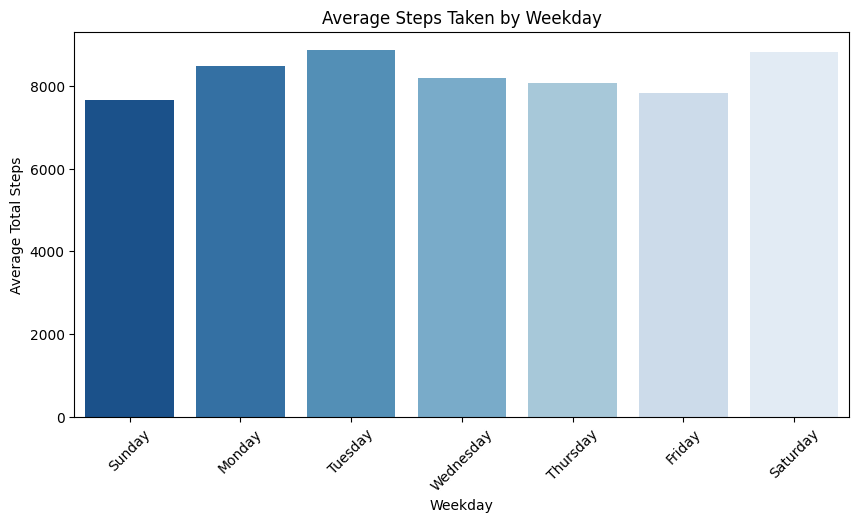

In [16]:
# --- Daily Activity ---

# Convert ActivityDate to datetime and extract weekday
activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate'])
activity_df['Weekday'] = activity_df['ActivityDate'].dt.day_name()


# Group by weekday
steps_by_day = activity_df.groupby('Weekday')['TotalSteps'].mean().reindex([
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=steps_by_day.index, y=steps_by_day.values, palette='Blues_r')
plt.title('Average Steps Taken by Weekday')
plt.ylabel('Average Total Steps')
plt.xticks(rotation=45)
plt.show()

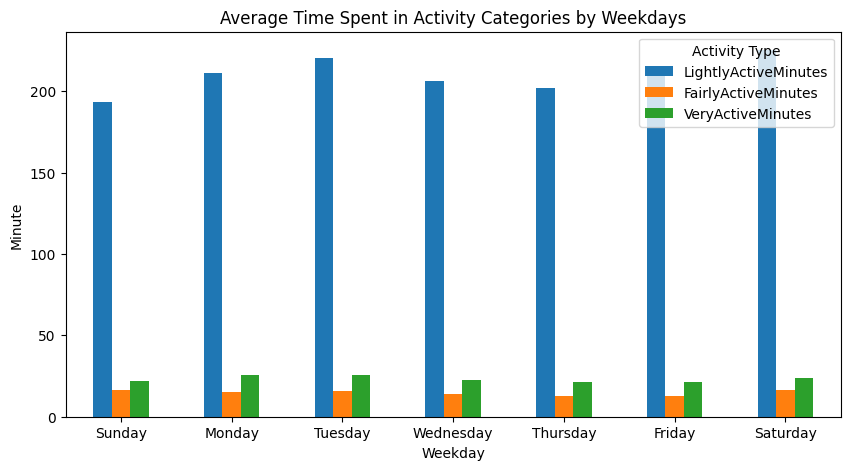

In [17]:
activity_minute = activity_df.groupby('Weekday')[[
    'LightlyActiveMinutes', 'FairlyActiveMinutes', 'VeryActiveMinutes'
]].mean().reindex(['Sunday','Monday','Tuesday', 'Wednesday','Thursday','Friday','Saturday'])

#Plot 
activity_minute.plot(kind = 'bar', figsize=(10,5))
plt.title('Average Time Spent in Activity Categories by Weekdays')
plt.ylabel('Minute')
plt.xticks(rotation=0)
plt.legend(title='Activity Type')
plt.show()

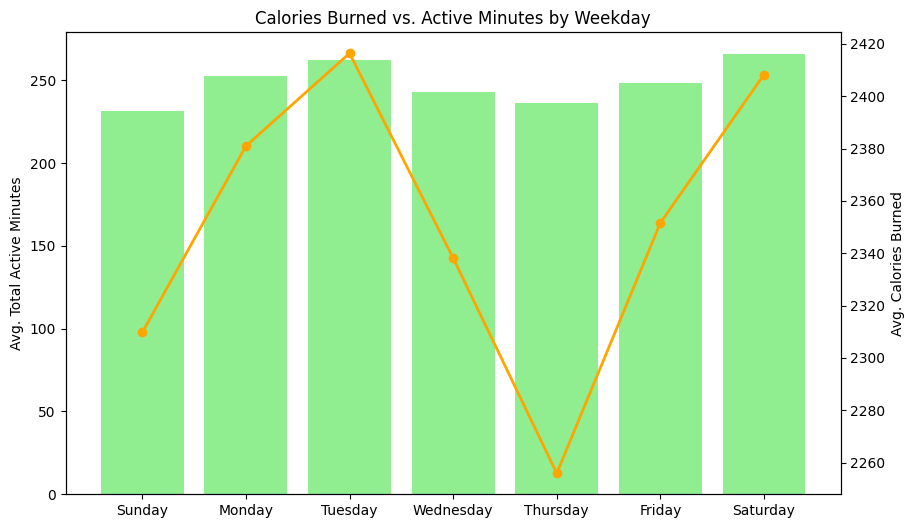

In [18]:
# Create a new column for total active minutes
activity_df['TotalActiveMinutes'] = activity_df['LightlyActiveMinutes'] + activity_df['FairlyActiveMinutes'] + activity_df['VeryActiveMinutes']

# Group and average by weekday
calories_df =  activity_df.groupby('Weekday')[['TotalActiveMinutes', 'Calories']].mean().reindex([
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])

# Plot dual-axis chart
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(calories_df.index, calories_df['TotalActiveMinutes'], color='lightgreen')
ax1.set_ylabel('Avg. Total Active Minutes')

ax2 = ax1.twinx()
ax2.plot(calories_df.index, calories_df['Calories'], color='orange', marker='o', linewidth=2)
ax2.set_ylabel('Avg. Calories Burned')

plt.title('Calories Burned vs. Active Minutes by Weekday')
plt.xticks(rotation=45)
plt.show()

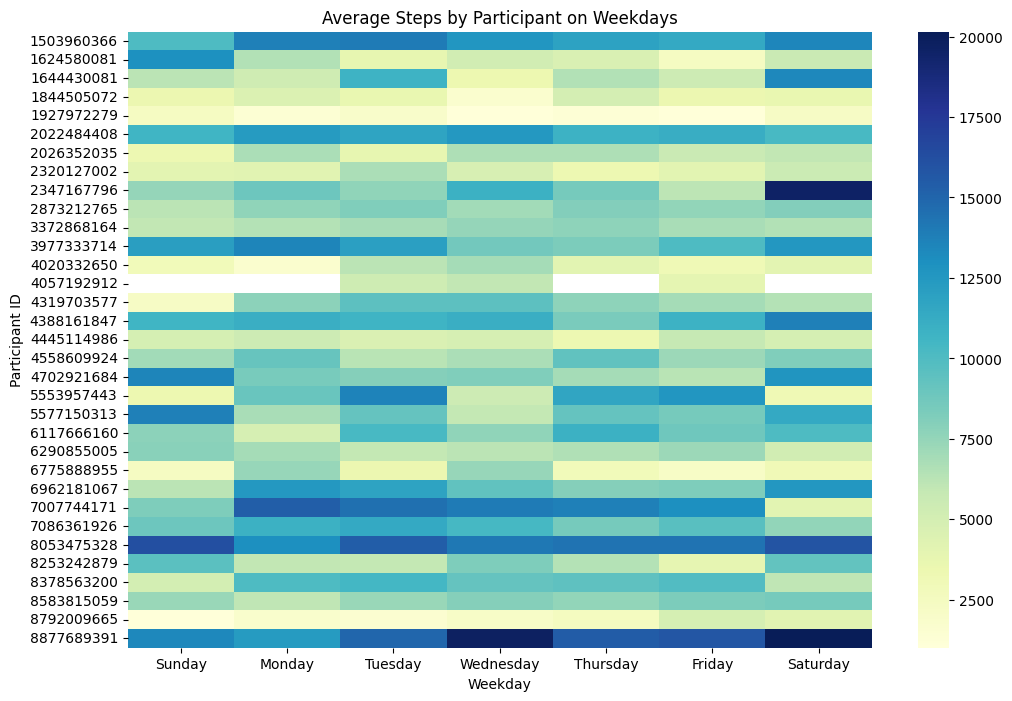

In [19]:
#activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate'])
#activity_df['Weekday'] = activity_df['ActivityDate'].dt.day_name()

# Pivot for heatmap
steps_heatmap = activity_df.pivot_table(
    index='Id', columns='Weekday', values='TotalSteps', aggfunc='mean'
).reindex(columns=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(steps_heatmap, cmap='YlGnBu')
plt.title('Average Steps by Participant on Weekdays')
plt.xlabel('Weekday')
plt.ylabel('Participant ID')
plt.show()


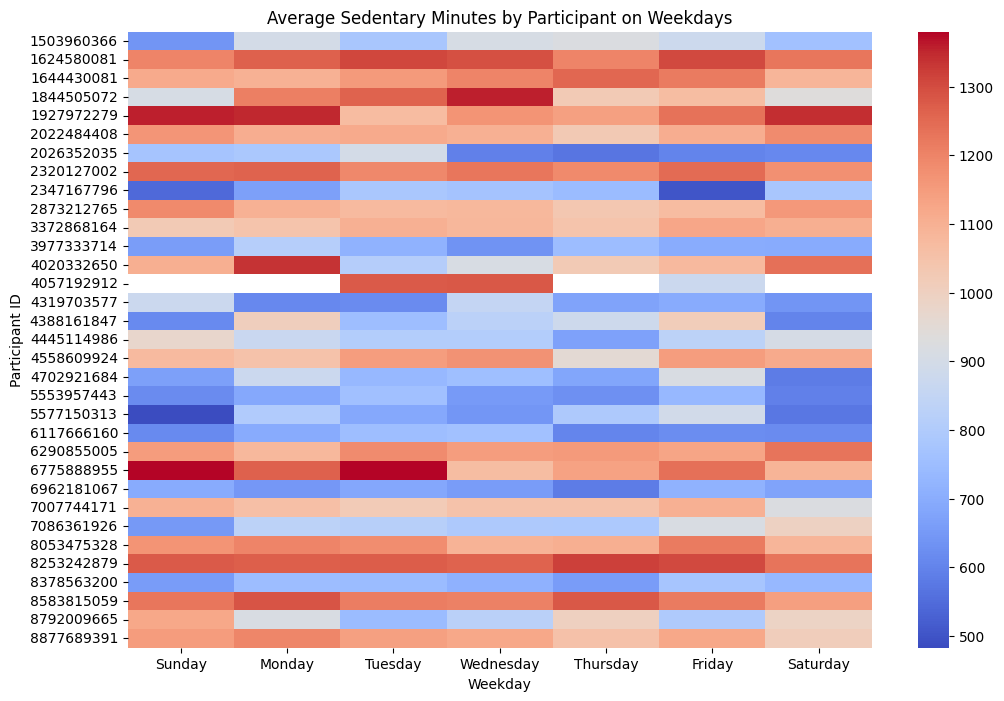

In [20]:
# Pivot for sedentary heatmap
sedentary_heatmap = activity_df.pivot_table(
    index='Id', columns='Weekday', values='SedentaryMinutes', aggfunc='mean'
).reindex(columns=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sedentary_heatmap, cmap='coolwarm')
plt.title('Average Sedentary Minutes by Participant on Weekdays')
plt.xlabel('Weekday')
plt.ylabel('Participant ID')
plt.show()

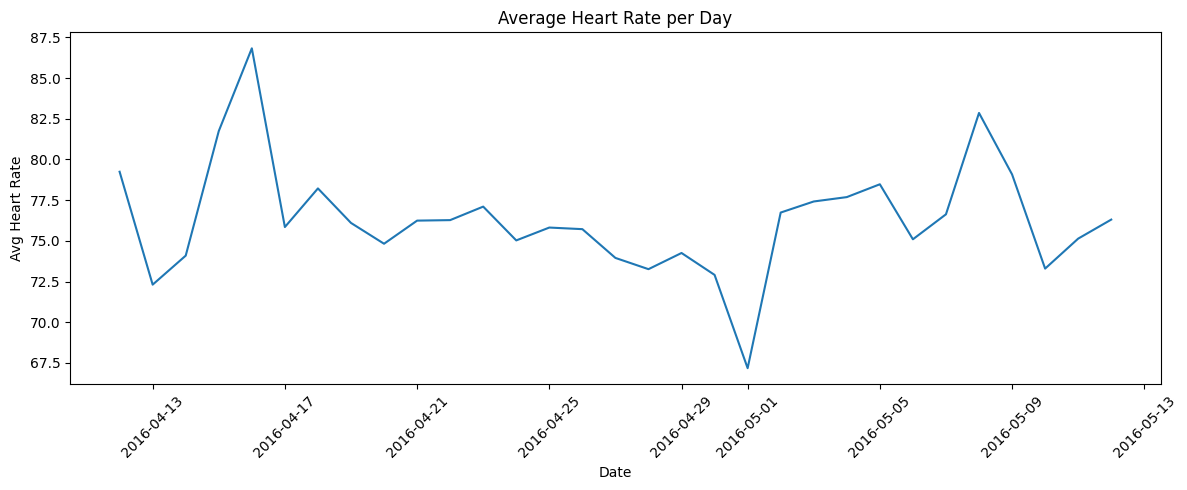

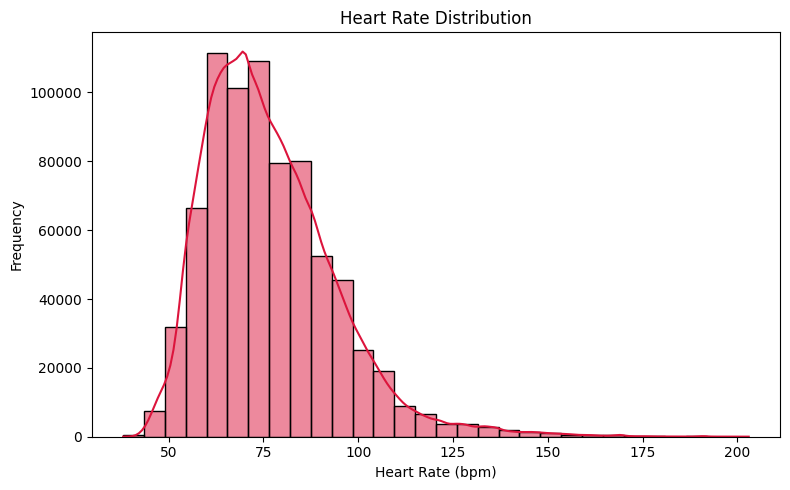

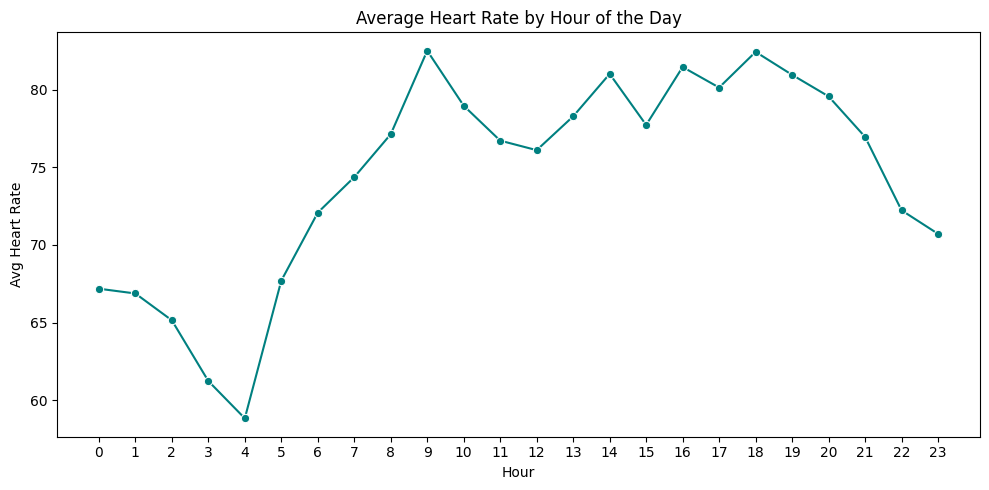

In [21]:
# --- Heart Rate Seconds ---

# Extract date and hour for grouping
heart_df['Date'] = heart_df['Time'].dt.date
heart_df['Hour'] = heart_df['Time'].dt.hour

# 1. Average Heart Rate per Day
avg_daily_hr = heart_df.groupby('Date')['Value'].mean()

plt.figure(figsize=(12, 5))
avg_daily_hr.plot()
plt.title('Average Heart Rate per Day')
plt.xlabel('Date')
plt.ylabel('Avg Heart Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Heart Rate Distribution
plt.figure(figsize=(8, 5))
sns.histplot(heart_df['Value'], bins=30, kde=True, color='crimson')
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Average Heart Rate by Hour of Day
avg_hr_by_hour = heart_df.groupby('Hour')['Value'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=avg_hr_by_hour.index, y=avg_hr_by_hour.values, marker='o', color='teal')
plt.title('Average Heart Rate by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Avg Heart Rate')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_20028\1850038362.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sleep.index, y=avg_sleep.values, palette='Purples_r')


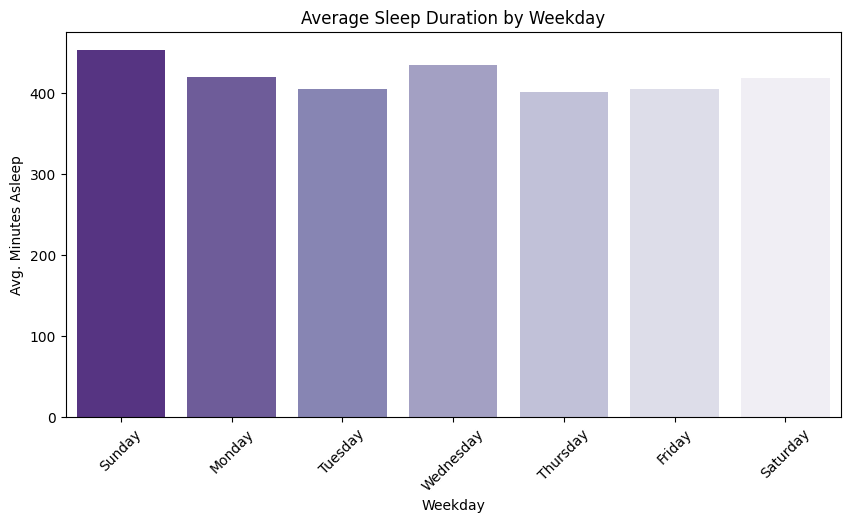

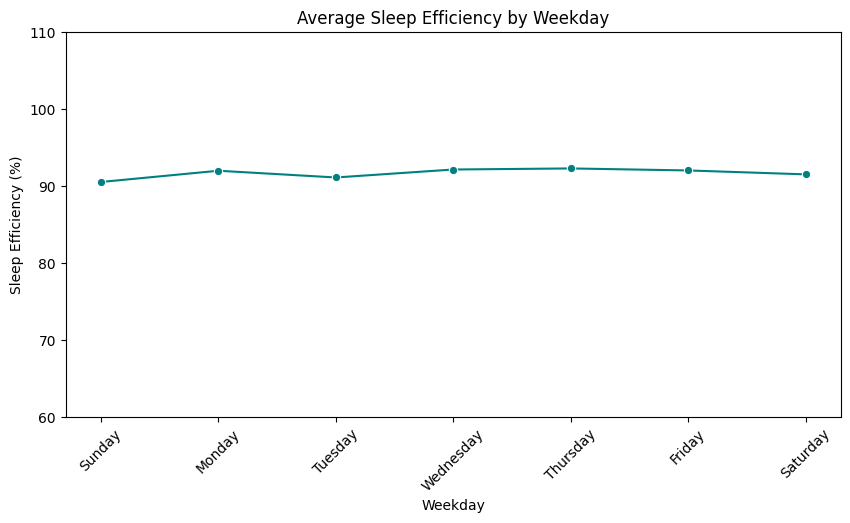

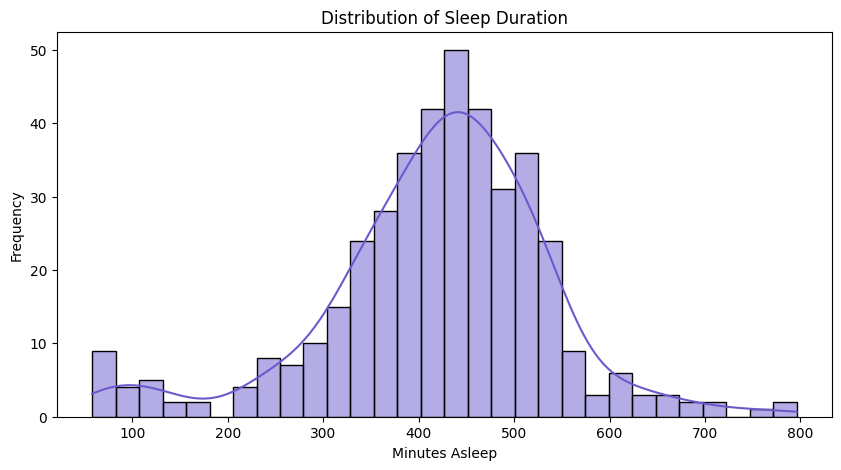

In [22]:
# --- Sleep Day ---

# Convert date column to datetime and extract weekday
sleepDay_df['SleepDay'] = pd.to_datetime(sleepDay_df['SleepDay'])
sleepDay_df['Weekday'] = sleepDay_df['SleepDay'].dt.day_name()

# Group by weekday and calculate average sleep
avg_sleep = sleepDay_df.groupby('Weekday')['TotalMinutesAsleep'].mean().reindex([
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=avg_sleep.index, y=avg_sleep.values, palette='Purples_r')
plt.title('Average Sleep Duration by Weekday')
plt.ylabel('Avg. Minutes Asleep')
plt.xticks(rotation=45)
plt.show()


# ---------------------------------------------------------------------------------


# Calculate sleep efficiency
sleepDay_df['SleepEfficiency'] = (sleepDay_df['TotalMinutesAsleep'] / sleepDay_df['TotalTimeInBed']) * 100

# Group by weekday
avg_efficiency = sleepDay_df.groupby('Weekday')['SleepEfficiency'].mean().reindex([
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
])

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(x=avg_efficiency.index, y=avg_efficiency.values, marker='o', color='teal')
plt.title('Average Sleep Efficiency by Weekday')
plt.ylabel('Sleep Efficiency (%)')
plt.xticks(rotation=45)
plt.ylim(60, 110)
plt.show()

# --------------------------------------------------------------------------------------------------

# Histogram of sleep minutes
plt.figure(figsize=(10,5))
sns.histplot(sleepDay_df['TotalMinutesAsleep'], bins=30, kde=True, color='slateblue')
plt.title('Distribution of Sleep Duration')
plt.xlabel('Minutes Asleep')
plt.ylabel('Frequency')
plt.show()

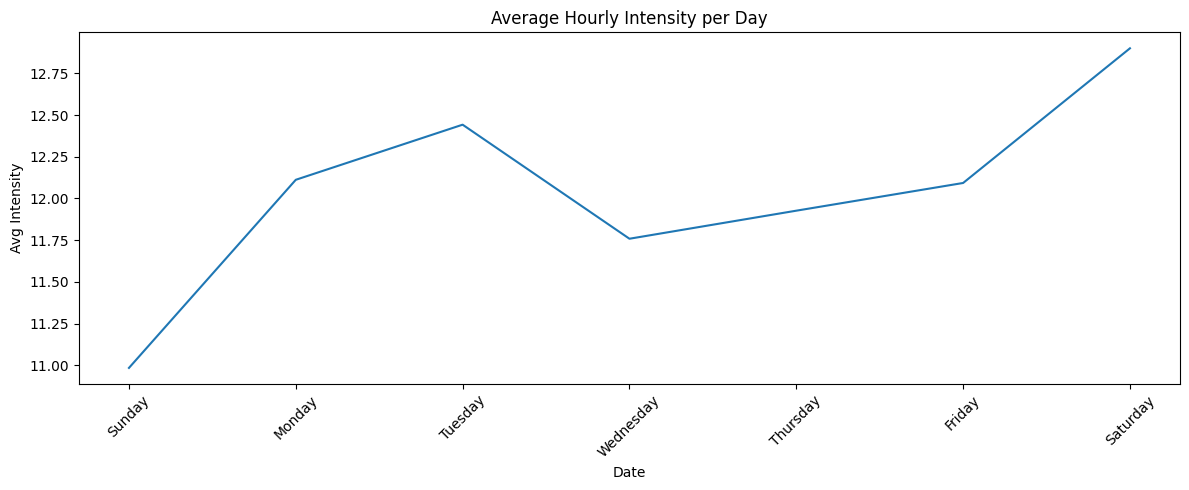

In [23]:
# --- Houlry Intensity --- 

# Extract date and hour for grouping
#hr_intensity_df['Date'] = hr_intensity_df['Time'].dt.date
#hr_intensity_df['Hour'] = hr_intensity_df['Time'].dt.hour
hr_intensity_df['SleepDay'] = pd.to_datetime(hr_intensity_df['ActivityHour'])
hr_intensity_df['Weekday'] = hr_intensity_df['ActivityHour'].dt.day_name()

# Group by weekday
avg_hourIntensity = hr_intensity_df.groupby('Weekday')['TotalIntensity'].mean().reindex([
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
])

plt.figure(figsize=(12, 5))
avg_hourIntensity.plot()
plt.title('Average Hourly Intensity per Day')
plt.xlabel('Date')
plt.ylabel('Avg Intensity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

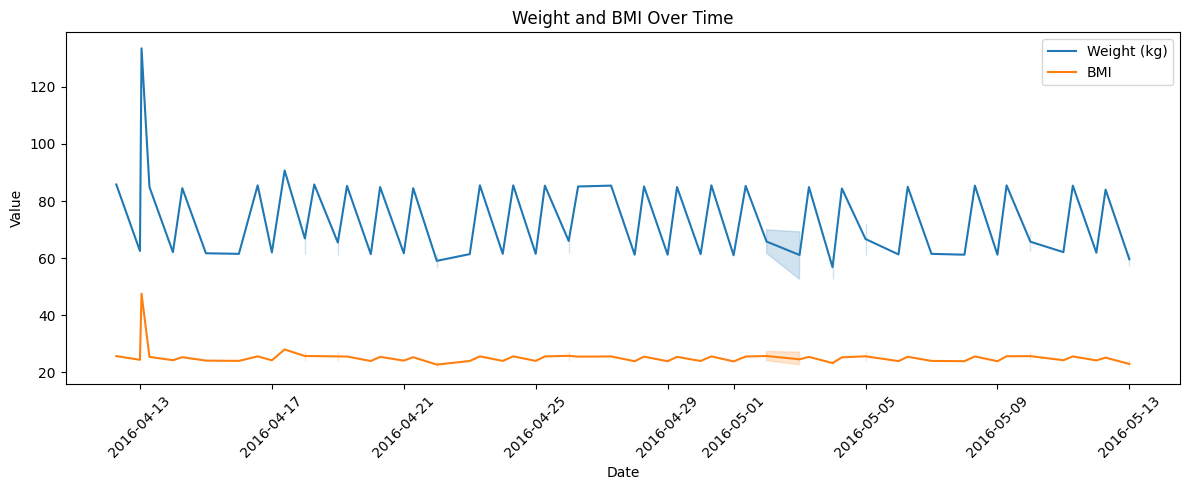

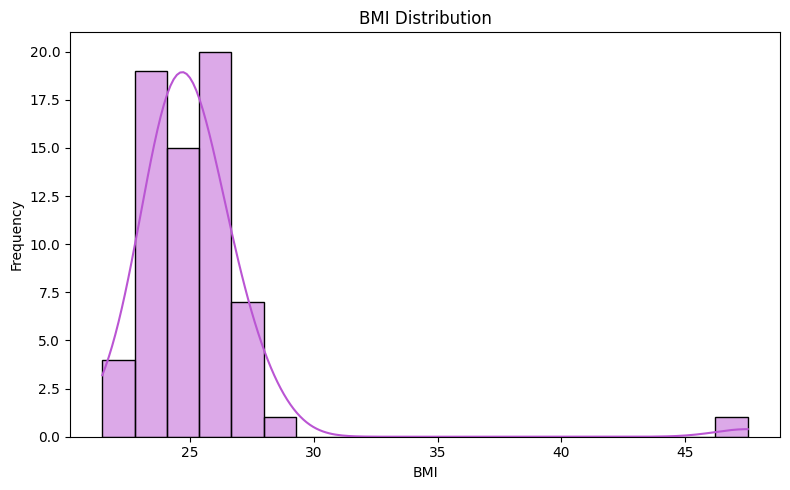

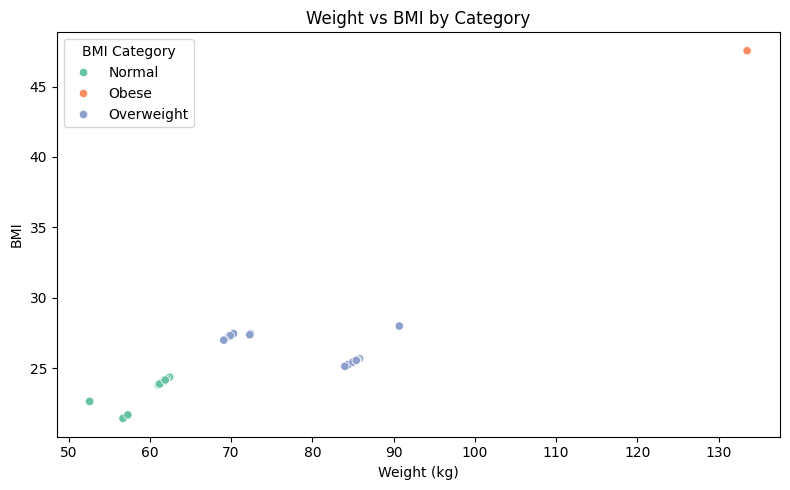

C:\Users\visha\AppData\Local\Temp\ipykernel_20028\2021118441.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BMI_Category', data=weightInfo_df, palette='Set2')


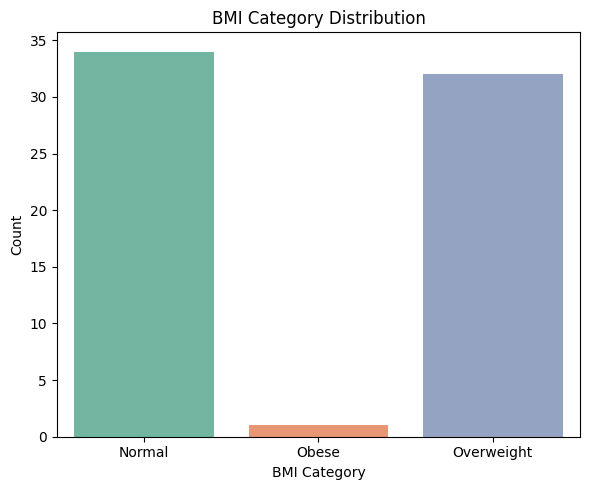

In [24]:
# --- Weight Log Info ---

# Convert the 'Date' column to datetime
weightInfo_df['Date'] = pd.to_datetime(weightInfo_df['Date'])

# Categorize BMI into health categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

weightInfo_df['BMI_Category'] = weightInfo_df['BMI'].apply(categorize_bmi)

# 1. Weight and BMI Over Time
plt.figure(figsize=(12, 5))
sns.lineplot(data=weightInfo_df, x='Date', y='WeightKg', label='Weight (kg)')
sns.lineplot(data=weightInfo_df, x='Date', y='BMI', label='BMI')
plt.title('Weight and BMI Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. BMI Distribution
plt.figure(figsize=(8, 5))
sns.histplot(weightInfo_df['BMI'], bins=20, kde=True, color='mediumorchid')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Weight vs BMI by Category
plt.figure(figsize=(8, 5))
sns.scatterplot(data=weightInfo_df, x='WeightKg', y='BMI', hue='BMI_Category', palette='Set2')
plt.title('Weight vs BMI by Category')
plt.xlabel('Weight (kg)')
plt.ylabel('BMI')
plt.legend(title='BMI Category')
plt.tight_layout()
plt.show()

# 4. BMI Category Distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='BMI_Category', data=weightInfo_df, palette='Set2')
plt.title('BMI Category Distribution')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# Strava Merging Datasets

In [25]:
import pandas as pd
from functools import reduce

# Read files and set the 'Date' (or your common key) as index immediately
daily = pd.read_csv(r'E:/Analytics PDF/Strava Fitness/cleaned_dailyActivity.csv')    #.set_index('Id')
heartrate = pd.read_csv(r'E:/Analytics PDF/Strava Fitness/cleaned_heartrate_seconds.csv')
hourly = pd.read_csv(r'E:/Analytics PDF/Strava Fitness/cleaned_hourlyIntensities_merged.csv')
sleep = pd.read_csv(r'E:/Analytics PDF/Strava Fitness/cleaned_sleepDay.csv')
weight = pd.read_csv(r'E:/Analytics PDF/Strava Fitness/cleaned_weightLogInfo.csv')

# Join them (This adds columns from df2 and df3 .. d5 to df1)

'''Join Limitation: The .join() method only supports lsuffix and rsuffix when joining two DataFrames. 
When you pass a list [df2, df3, df4, df5], those parameters are no longer valid.
# how='outer' ensures you don't lose rows if one file has a date the other doesn't

#combined_Activity_df = df1.join([df2, df3, df4, df5], axis=1, how='outer')
combined_Activity_df = [df1, df2, df3, df4, df5]
# merge on the 'Id' index across all dataframes
combined_Activity_df = reduce(lambda left, right: pd.merge(left, right, on='Id', how='outer'), combined_Activity_df)'''

#Convert Date Columns
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
hourly['ActivityHour'] = pd.to_datetime(hourly['ActivityHour'])
heartrate['Time'] = pd.to_datetime(heartrate['Time'])
weight['Date'] = pd.to_datetime(weight['Date'])

# Create Common Merge Date
daily['date'] = daily['ActivityDate'].dt.date
sleep['date'] = sleep['SleepDay'].dt.date
hourly['date'] = hourly['ActivityHour'].dt.date
heartrate['date'] = heartrate['Time'].dt.date
weight['date'] = weight['Date'].dt.date

# Aggregate Hourly → Daily
hourly_daily = hourly.groupby(['Id','date']).agg({
    'TotalIntensity':'sum',
    'AverageIntensity':'mean'
}).reset_index()

# Aggregate Heart Rate → Daily
heartrate_daily = heartrate.groupby(['Id','date']).agg({
    'Value':['mean','max','min']
}).reset_index()

heartrate_daily.columns = ['Id','date','avg_heartrate','max_heartrate','min_heartrate']

#print(combined_Activity_df.head())
#print(list(sleepDay_df.columns))

In [26]:
# Prepare Sleep Table
sleep_daily = sleep[['Id','date','TotalMinutesAsleep','TotalTimeInBed']]

# Prepare Weight Table
weight_daily = weight[['Id','date','WeightKg','BMI']]

# Merge Everything
merged = pd.merge(daily, sleep_daily, on=['Id','date'], how='left')

# -- Merge hourly intensity:
merged = pd.merge(merged, hourly_daily, on=['Id','date'], how='left')

# -- Merge heart rate:
merged = pd.merge(merged, heartrate_daily, on=['Id','date'], how='left')

# -- Merge weight:
merged = pd.merge(merged, weight_daily, on=['Id','date'], how='left')

# Final Cleaning    
merged.drop_duplicates(inplace=True)

merged.fillna(0, inplace=True)

merged.info()

# Save Final Dataset
merged.to_csv("bellabeat_master_dataset.csv", index=False, encoding='utf-8')

merged.head()
#merged.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        861 non-null    int64         
 1   ActivityDate              861 non-null    datetime64[ns]
 2   TotalSteps                861 non-null    int64         
 3   TotalDistance             861 non-null    float64       
 4   TrackerDistance           861 non-null    float64       
 5   LoggedActivitiesDistance  861 non-null    float64       
 6   VeryActiveDistance        861 non-null    float64       
 7   ModeratelyActiveDistance  861 non-null    float64       
 8   LightActiveDistance       861 non-null    float64       
 9   SedentaryActiveDistance   861 non-null    float64       
 10  VeryActiveMinutes         861 non-null    int64         
 11  FairlyActiveMinutes       861 non-null    int64         
 12  LightlyActiveMinutes  

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,date,TotalMinutesAsleep,TotalTimeInBed,TotalIntensity,AverageIntensity,avg_heartrate,max_heartrate,min_heartrate,WeightKg,BMI
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,2016-04-12,327.0,346.0,429.0,0.297917,0.0,0.0,0.0,0.0,0.0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,2016-04-13,384.0,407.0,318.0,0.220833,0.0,0.0,0.0,0.0,0.0
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,2016-04-14,0.0,0.0,293.0,0.203472,0.0,0.0,0.0,0.0,0.0
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,2016-04-15,412.0,442.0,364.0,0.252778,0.0,0.0,0.0,0.0,0.0
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,2016-04-16,340.0,367.0,349.0,0.242361,0.0,0.0,0.0,0.0,0.0


# Merged EDA Analysis

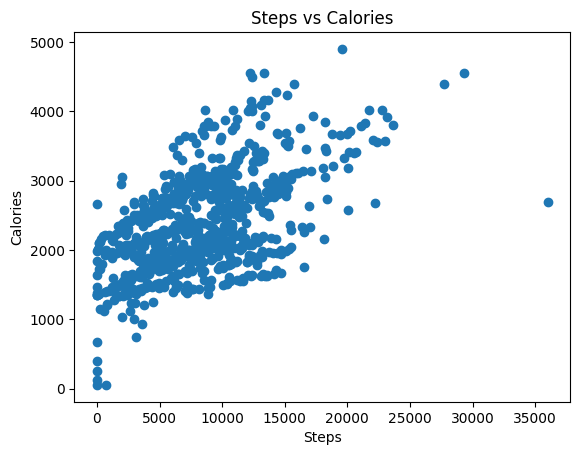

In [27]:
# Steps vs Calories 

plt.scatter(merged['TotalSteps'], merged['Calories'])
plt.xlabel("Steps")
plt.ylabel("Calories")
plt.title("Steps vs Calories")
plt.show()

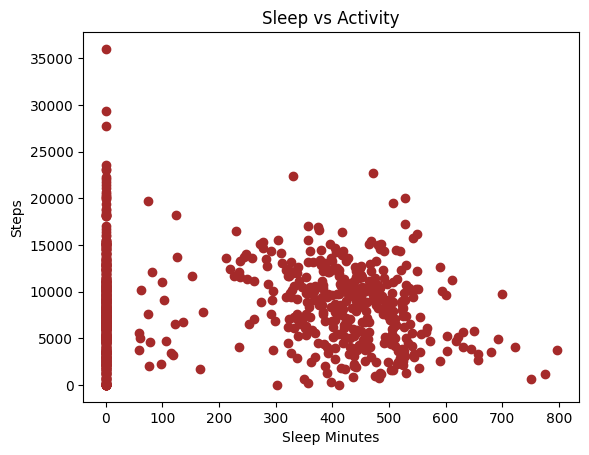

In [28]:
#Sleep vs Steps 

plt.scatter(merged['TotalMinutesAsleep'], merged['TotalSteps'], color="brown")
plt.xlabel("Sleep Minutes")
plt.ylabel("Steps")
plt.title("Sleep vs Activity")
plt.show()

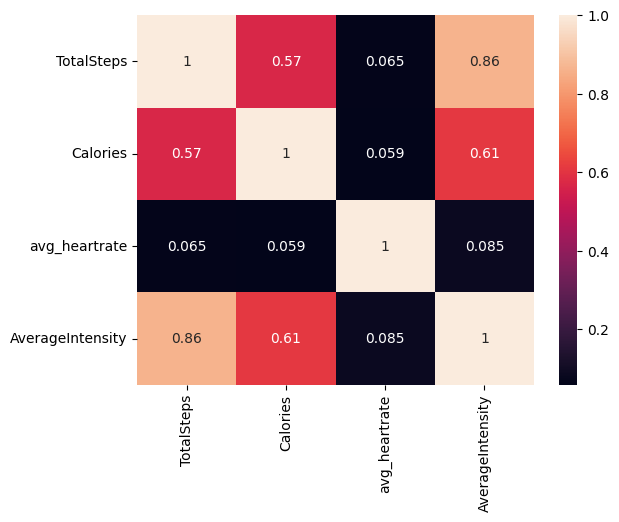

In [29]:
#Correlation Matrix 

sns.heatmap(
    merged[['TotalSteps','Calories','avg_heartrate','AverageIntensity']].corr(),
    annot=True
)
plt.show()

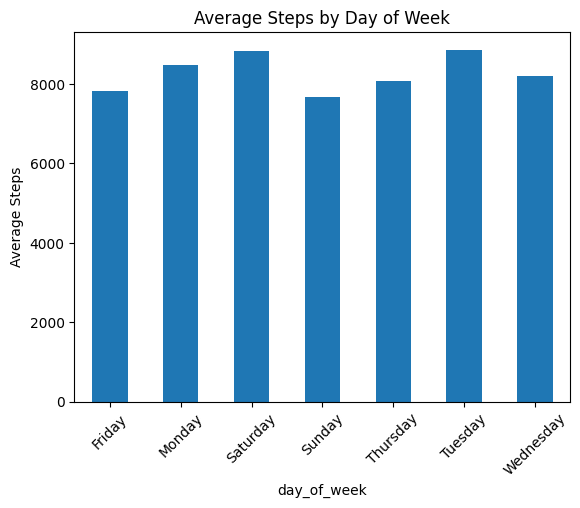

In [30]:
#Average Steps by Day of Week 

merged['day_of_week'] = pd.to_datetime(merged['date']).dt.day_name()

avg_steps_day = merged.groupby('day_of_week')['TotalSteps'].mean()

avg_steps_day.plot(kind='bar')
plt.title("Average Steps by Day of Week")
plt.ylabel("Average Steps")
plt.xticks(rotation = 45)
plt.show()

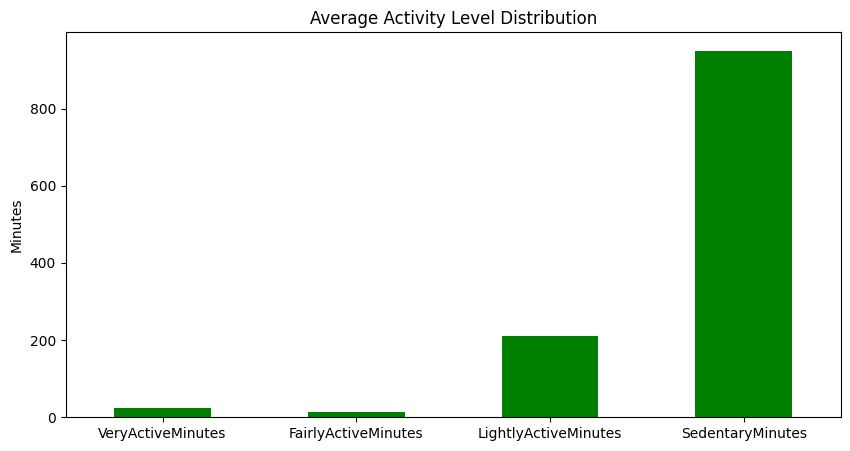

In [31]:
# Activity Type Distribution

activity_means = merged[['VeryActiveMinutes','FairlyActiveMinutes',
                         'LightlyActiveMinutes','SedentaryMinutes']].mean()

activity_means.plot(kind='bar', figsize= (10,5), color = 'green')
plt.title("Average Activity Level Distribution")
plt.ylabel("Minutes")
plt.xticks(rotation = 0)
plt.show()

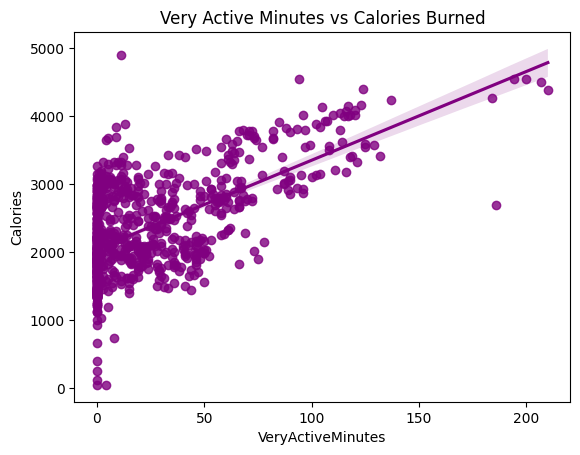

In [32]:
# Calories Burned vs Activity Minutes

sns.regplot(x='VeryActiveMinutes', y='Calories', data=merged, color='purple')
plt.title("Very Active Minutes vs Calories Burned")
plt.show()

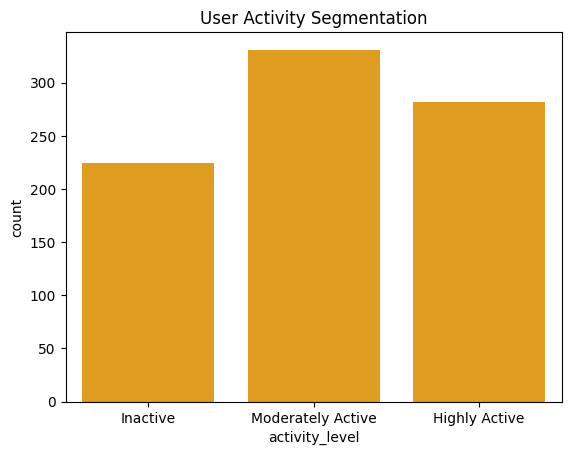

----------------------------------------- END -----------------------------------------------


In [33]:
#Steps Distribution (User Segmentation)

merged['activity_level'] = pd.cut(
    merged['TotalSteps'],
    bins=[0,5000,10000,20000],
    labels=['Inactive','Moderately Active','Highly Active']
)

sns.countplot(x='activity_level', data=merged, color= "Orange")
plt.title("User Activity Segmentation")
plt.show()

print("----------------------------------------- END -----------------------------------------------")